# Quante sezioni di censimento considerare nel ranking dei GAP score critici

**Obiettivo di questo notebook:** partendo dal `gap_score` già calcolato per ogni sezione di
censimento italiana, determinare **in modo non arbitrario** quante sezioni includere nel
ranking delle situazioni più critiche (i "deserti di ricarica" più gravi), applicando il
**metodo del gomito (elbow method)**.

Struttura:
1. Come si ottiene il `gap_score` (richiamo alla metodologia definitiva del progetto)
2. Caricamento dati e distribuzione del `gap_score`
3. Spiegazione del metodo del gomito
4. Applicazione del metodo alla curva ordinata dei GAP score
5. Risultato: numero di sezioni critiche e verifica di robustezza


## 1. Come si ottiene il `gap_score`

Il punteggio usato in questo notebook **non viene ricalcolato qui**: proviene dalla pipeline
definitiva del progetto (`gap_score_DEFINITIVO.ipynb`, cartella Drive `4_GAP_SCORE`), che lo
calcola così:

$$\boxed{\;\text{GAP}_i = \text{rank\%}(D_i)\; -\; \text{rank\%}(S_i)\;}$$

dove, per ogni sezione di censimento eleggibile $i$:

- $D_i$ = **domanda** effettiva di ricarica pubblica (veicoli da ricaricare stimati, corretti
  per il bias delle flotte a noleggio e per la fattibilità di ricarica domestica);
- $S_i$ = **accessibilità dell'offerta** di ricarica (colonnine entro 500 m se la sezione è
  servita, altrimenti prossimità della colonnina più vicina);
- $\text{rank\%}$ = rango percentile nazionale, calcolato **solo** sulle sezioni eleggibili
  (abitate, non speciali, con popolazione in età di guida > 0).

Il punteggio è quindi sempre in $[-1, +1]$:

| Valore | Significato |
|---|---|
| vicino a **+1** | **deserto**: tanta domanda, offerta pressoché assente |
| vicino a **0** | sezione equilibrata (domanda e offerta hanno rango simile) |
| vicino a **-1** | sezione ben servita: offerta superiore alla domanda relativa |

Le sezioni non eleggibili hanno `gap_score = NaN` e vengono escluse da questa analisi.

In questo notebook usiamo direttamente l'output di quella pipeline (`gap_score_definitivo.csv`,
colonne `SEZ2011` e `gap_score`): qui ci concentriamo esclusivamente sulla domanda successiva,
cioè **quante sezioni, tra quelle con GAP più alto, meritano di entrare nel ranking dei casi
prioritari**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

from pathlib import Path

# gap_score_definitivo.csv: output del notebook 08, versionato anche in data/.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PATH = next((p for p in (REPO / "output" / "gap_score_definitivo.csv",
                         REPO / "data" / "gap_score_definitivo.csv") if p.exists()),
            REPO / "data" / "gap_score_definitivo.csv")
df = pd.read_csv(PATH)

print(f"Righe totali nel file:         {len(df):,}")
df = df.dropna(subset=["gap_score"]).copy()
print(f"Sezioni eleggibili (non NaN):  {len(df):,}")
df = df.sort_values("gap_score", ascending=False).reset_index(drop=True)
df.head()


Righe totali nel file:         402,678
Sezioni eleggibili (non NaN):  346,507


,SEZ2011,gap_score
0,770080000016,0.975747
1,520340000039,0.974263
2,480030000002,0.963620
3,580050000024,0.962921
4,360420000002,0.962855


## 2. Distribuzione del `gap_score`

Prima di tagliare la lista da qualche parte, guardiamo come si distribuiscono i valori:
forma, code, eventuali salti o accumuli.


In [2]:
stats = df["gap_score"].describe(percentiles=[.01,.05,.10,.25,.5,.75,.90,.95,.99])
stats.round(4)


count    346507.0000
mean         -0.0000
std           0.3116
min          -0.9988
1%           -0.7725
5%           -0.5420
10%          -0.4131
25%          -0.1899
50%           0.0075
75%           0.2001
90%           0.3964
95%           0.5143
99%           0.7110
max           0.9757
Name: gap_score, dtype: float64

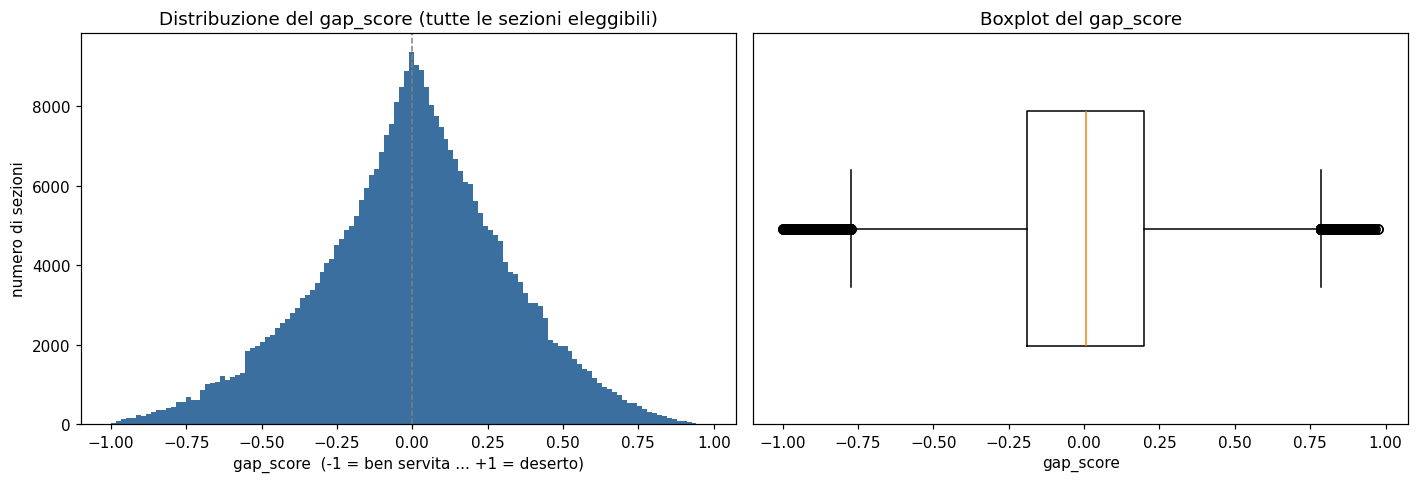

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["gap_score"], bins=120, color="#3b6fa0", edgecolor="none")
axes[0].axvline(0, color="grey", linestyle="--", linewidth=1)
axes[0].set_title("Distribuzione del gap_score (tutte le sezioni eleggibili)")
axes[0].set_xlabel("gap_score  (-1 = ben servita ... +1 = deserto)")
axes[0].set_ylabel("numero di sezioni")

axes[1].boxplot(df["gap_score"], vert=False, widths=0.6)
axes[1].set_title("Boxplot del gap_score")
axes[1].set_xlabel("gap_score")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()


**Lettura**: la distribuzione è centrata vicino allo zero (per costruzione: è una
differenza fra due ranghi percentili, quindi simmetrica in media) con code verso ±1. Le
sezioni che ci interessano — i deserti critici — sono quelle nella **coda destra**, con
`gap_score` alto. Il boxplot aiuta a vedere dove iniziano i valori "anomali" secondo la
regola classica (1.5×IQR), ma da solo non basta a decidere un taglio: la distribuzione va
guardata in forma di **ranking ordinato**, che è ciò che fa il metodo del gomito.


## 3. Il metodo del gomito, spiegato in modo semplice

Immagina di ordinare **tutte** le sezioni dalla più critica (gap_score più alto) alla meno
critica, e di disegnare un grafico: sull'asse orizzontale la posizione in classifica (1ª,
2ª, 3ª, ...), sull'asse verticale il suo gap_score.

Questa curva parte in alto (le sezioni peggiori) e scende verso il basso (le sezioni meno
critiche). La domanda "quante sezioni considerare?" equivale a chiedersi: **fino a che punto
scendendo lungo questa curva sto ancora selezionando casi genuinamente critici, prima che la
curva si appiattisca in valori ordinari?**

Il **metodo del gomito** individua esattamente questo punto: il punto in cui la curva smette
di scendere ripidamente e comincia ad "appiattirsi" — proprio come il gomito di un braccio
piegato. Geometricamente:

1. Si traccia una linea retta immaginaria dal primo punto della curva (la sezione più
   critica) all'ultimo (la sezione meno critica).
2. Per ogni punto della curva si misura **quanto si allontana** da quella linea retta.
3. Il punto che si allontana **di più** è il "gomito": è lì che la curva ha la massima
   curvatura, il salto più netto tra "gruppo critico" e "il resto".

Perché funziona bene qui: se il fenomeno ha davvero un gruppo di sezioni straordinariamente
critiche rispetto alla massa, la curva ordinata mostra un tratto ripido iniziale (i pochi
casi gravi) seguito da un tratto quasi piatto (la maggioranza delle sezioni, con gap_score
via via meno estremo). Il gomito è il punto dove finisce il tratto ripido: è un taglio che
**nasce dalla forma dei dati stessi**, non da una percentuale scelta a tavolino (es. "il primo
5%") o da un numero deciso arbitrariamente (es. "le prime 200").

Va detto anche il suo limite: se la curva è liscia e non ha un vero cambio di pendenza (cioè
il gap_score decresce in modo graduale senza un salto netto), il gomito individuato è meno
"naturale" e va interpretato con più cautela — per questo, più sotto, confrontiamo il
risultato con un criterio alternativo (soglia statistica) come verifica di robustezza.


## 4. Applicazione del metodo alla curva dei GAP score

Applichiamo il metodo del gomito **solo sulla parte di curva che ci interessa**: la coda dei
`gap_score` positivi (i potenziali deserti). Includere anche le sezioni "ben servite"
(gap_score molto negativo) sposterebbe inutilmente la retta di riferimento e non è la
domanda che ci poniamo — a noi interessa solo dove finisce il gruppo critico.


In [4]:
def trova_gomito(y_ordinato):
    # Restituisce l'indice (0-based) del punto di massima distanza dalla corda
    # che unisce primo e ultimo punto della curva y_ordinato (gia' ordinata in
    # modo decrescente).
    n = len(y_ordinato)
    x = np.arange(n, dtype=float)
    y = np.asarray(y_ordinato, dtype=float)

    # normalizzo entrambi gli assi in [0, 1] per rendere la distanza confrontabile
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())

    # corda dal primo all'ultimo punto
    x1, y1 = x_n[0], y_n[0]
    x2, y2 = x_n[-1], y_n[-1]

    # distanza perpendicolare di ogni punto dalla retta (x1,y1)-(x2,y2)
    num = np.abs((y2 - y1) * x_n - (x2 - x1) * y_n + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    distanza = num / den

    return int(np.argmax(distanza)), distanza

# coda critica: solo gap_score positivi, ordinati dal più alto
critiche = df[df["gap_score"] > 0].reset_index(drop=True)
y = critiche["gap_score"].to_numpy()

idx_gomito, distanza = trova_gomito(y)
n_sezioni_gomito = idx_gomito + 1  # +1 perché idx e' 0-based

print(f"Sezioni con gap_score > 0:            {len(critiche):,}")
print(f"Indice del gomito:                    {idx_gomito:,}")
print(f"Numero di sezioni fino al gomito:      {n_sezioni_gomito:,}")
print(f"gap_score al gomito:                   {y[idx_gomito]:.4f}")


Sezioni con gap_score > 0:            177,501
Indice del gomito:                    28,663
Numero di sezioni fino al gomito:      28,664
gap_score al gomito:                   0.4287


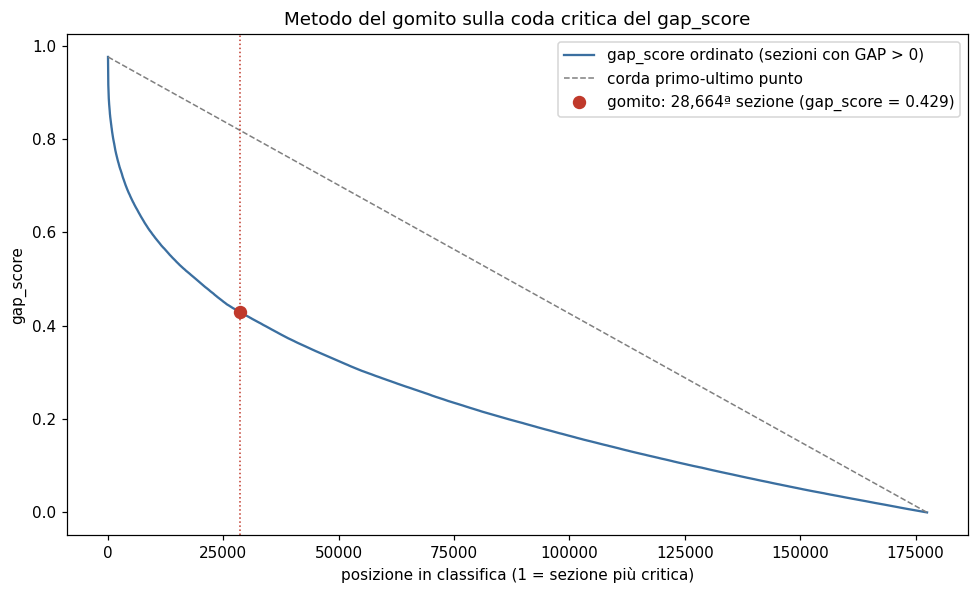

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(1, len(y) + 1)
ax.plot(x, y, color="#3b6fa0", linewidth=1.5, label="gap_score ordinato (sezioni con GAP > 0)")
ax.plot([x[0], x[-1]], [y[0], y[-1]], color="grey", linestyle="--", linewidth=1,
        label="corda primo-ultimo punto")
ax.scatter([x[idx_gomito]], [y[idx_gomito]], color="#c0392b", zorder=5, s=60,
           label=f"gomito: {n_sezioni_gomito:,}ª sezione (gap_score = {y[idx_gomito]:.3f})")
ax.axvline(x[idx_gomito], color="#c0392b", linestyle=":", linewidth=1)

ax.set_xlabel("posizione in classifica (1 = sezione più critica)")
ax.set_ylabel("gap_score")
ax.set_title("Metodo del gomito sulla coda critica del gap_score")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Robustezza: confronto con una soglia statistica

Il gomito geometrico può essere sensibile alla forma esatta della curva. Come verifica,
confrontiamo il numero di sezioni trovato con due criteri alternativi, entrambi coerenti
con le convenzioni già usate nel progetto per l'IDI (rango percentile / z-score robusto):

- **percentile**: quante sezioni superano il 95° e il 99° percentile nazionale del gap_score;
- **z-score robusto** (mediana / IQR, la stessa trasformazione usata per l'IDI): quante
  sezioni hanno uno z-score robusto oltre 1.5 e oltre 2.

Se il numero trovato dal gomito cade in un intervallo plausibile rispetto a questi criteri,
è un buon segno che il taglio non sia un artefatto della curva ma rifletta un gruppo
davvero distinto di sezioni.


In [6]:
from scipy import stats as sps

soglie_percentile = {}
for p in [95, 99]:
    soglia = np.percentile(df["gap_score"], p)
    n = int((df["gap_score"] >= soglia).sum())
    soglie_percentile[p] = (soglia, n)
    print(f"Percentile {p}:  soglia gap_score >= {soglia:.4f}  ->  {n:,} sezioni")

mediana = df["gap_score"].median()
iqr = sps.iqr(df["gap_score"])
robust_z = (df["gap_score"] - mediana) / iqr

print()
for z in [1.5, 2.0]:
    n = int((robust_z >= z).sum())
    print(f"z-score robusto >= {z}:  -> {n:,} sezioni")

print()
print(f"Metodo del gomito:        -> {n_sezioni_gomito:,} sezioni")


Percentile 95:  soglia gap_score >= 0.5143  ->  17,326 sezioni
Percentile 99:  soglia gap_score >= 0.7110  ->  3,466 sezioni

z-score robusto >= 1.5:  -> 9,915 sezioni
z-score robusto >= 2.0:  -> 1,374 sezioni

Metodo del gomito:        -> 28,664 sezioni


## 6. Conclusione

Il numero di sezioni suggerito dal metodo del gomito è quello stampato sopra
(`n_sezioni_gomito`): rappresenta il punto in cui la classifica dei GAP score smette di
scendere ripidamente, cioè dove finisce — nei dati stessi, non per scelta arbitraria — il
gruppo delle sezioni davvero critiche.

Il confronto con le soglie percentile e z-score serve a validare che il numero non sia un
artefatto della curva: se i tre criteri restituiscono ordini di grandezza compatibili, il
taglio del gomito è difendibile come criterio principale, con gli altri due come nota
metodologica a supporto nella documentazione del progetto.


In [7]:
top_gomito = critiche.iloc[:n_sezioni_gomito][["SEZ2011", "gap_score"]].reset_index(drop=True)
print(f"Sezioni critiche selezionate dal metodo del gomito: {len(top_gomito):,}")
top_gomito.head(10)


Sezioni critiche selezionate dal metodo del gomito: 28,664


,SEZ2011,gap_score
0,770080000016,0.975747
1,520340000039,0.974263
2,480030000002,0.963620
3,580050000024,0.962921
4,360420000002,0.962855
5,350080000020,0.956973
6,480450000016,0.955559
7,730070000017,0.955155
8,520260000002,0.954145
9,710280000033,0.952150
